In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

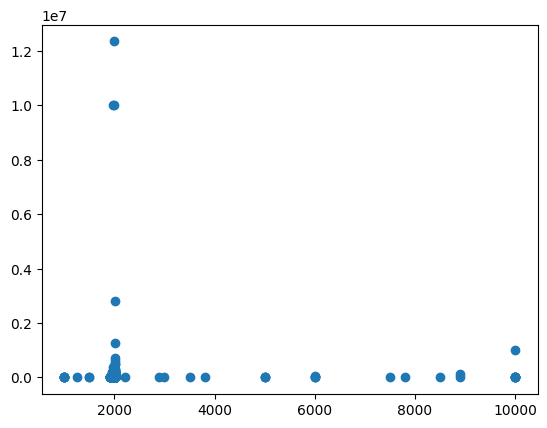

In [7]:
cars_data = pd.read_csv("cars_sampled.csv")
plt.scatter(cars_data["yearOfRegistration"], cars_data["price"])
plt.show()

In [12]:
#```python
# -*- coding: utf-8 -*-
"""
Personal Income Classification using K-Nearest Neighbors (KNN)
"""

# =============================================================================
# IMPORT REQUIRED LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


# =============================================================================
# IMPORT DATA
# =============================================================================

# Make sure income.csv is in the same folder as this Python file/Jupyter Notebook
data = pd.read_csv("income.csv", na_values=[" ?"])

print("Original Dataset Shape:", data.shape)
print("\nMissing Values:")
print(data.isnull().sum())


# =============================================================================
# DATA PRE-PROCESSING
# =============================================================================

# Display rows containing at least one missing value
missing = data[data.isnull().any(axis=1)]

print("\nRows with Missing Values:", len(missing))


# Remove rows containing missing values
data2 = data.dropna(axis=0).copy()

print("Dataset Shape After Removing Missing Values:", data2.shape)


# =============================================================================
# CONVERT TARGET VARIABLE
# =============================================================================

# Convert salary status into numerical values
# 0 = <= 50,000
# 1 = > 50,000

data2["SalStat"] = data2["SalStat"].map({
    " less than or equal to 50,000": 0,
    " greater than 50,000": 1
})

print("\nSalary Status:")
print(data2["SalStat"].value_counts())


# =============================================================================
# CONVERT CATEGORICAL VARIABLES INTO NUMERICAL VARIABLES
# =============================================================================

new_data = pd.get_dummies(data2, drop_first=True)

print("\nEncoded Dataset:")
print(new_data.head())


# =============================================================================
# SEPARATE FEATURES AND TARGET
# =============================================================================

# Target variable
y = new_data["SalStat"].values

# Input features
features = list(new_data.columns)
features.remove("SalStat")

x = new_data[features].values

print("\nNumber of Features:", len(features))
print("Feature Names:")
print(features)


# =============================================================================
# TRAIN-TEST SPLIT
# =============================================================================

train_x, test_x, train_y, test_y = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=0
)

print("\nTraining Data:", train_x.shape)
print("Testing Data:", test_x.shape)


# =============================================================================
# K-NEAREST NEIGHBORS (KNN)
# =============================================================================

# Create KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_classifier.fit(train_x, train_y)

# Predict test data
prediction = knn_classifier.predict(test_x)


# =============================================================================
# MODEL EVALUATION
# =============================================================================

# Confusion Matrix
confusion_matrix_result = confusion_matrix(test_y, prediction)

print("\nConfusion Matrix:")
print(confusion_matrix_result)


# Accuracy
accuracy = accuracy_score(test_y, prediction)

print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


# Misclassified samples
misclassified = (test_y != prediction).sum()

print("Misclassified Samples:", misclassified)


# =============================================================================
# EFFECT OF K VALUE
# =============================================================================

misclassified_samples = []

# Test K values from 1 to 19
for k in range(1, 20):

    knn = KNeighborsClassifier(n_neighbors=k)

    # Train model
    knn.fit(train_x, train_y)

    # Predict test data
    prediction_k = knn.predict(test_x)

    # Count misclassified samples
    error = (test_y != prediction_k).sum()

    misclassified_samples.append(error)


# Display misclassified samples for each K
print("\nMisclassified Samples for Different K Values:")

for k, error in zip(range(1, 20), misclassified_samples):
    print(f"K = {k}: {error} misclassified samples")


# =============================================================================
# END OF SCRIPT
# =============================================================================



Original Dataset Shape: (31978, 13)

Missing Values:
age                 0
JobType          1809
EdType              0
maritalstatus       0
occupation       1816
relationship        0
race                0
gender              0
capitalgain         0
capitalloss         0
hoursperweek        0
nativecountry       0
SalStat             0
dtype: int64

Rows with Missing Values: 1816
Dataset Shape After Removing Missing Values: (30162, 13)

Salary Status:
SalStat
0    22654
1     7508
Name: count, dtype: int64

Encoded Dataset:
   age  capitalgain  capitalloss  hoursperweek  SalStat  JobType_ Local-gov  \
0   45            0            0            28        0               False   
1   24            0            0            40        0               False   
2   44            0            0            40        1               False   
3   27            0            0            40        0               False   
4   20            0            0            35        0               Fals

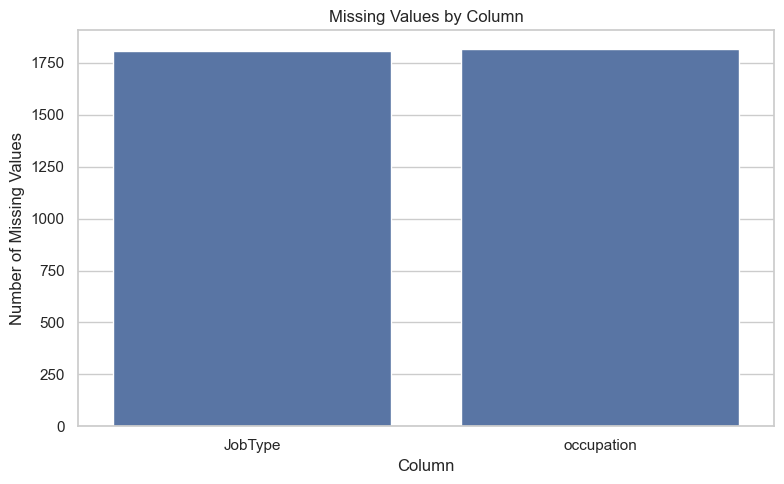

In [16]:
# =============================================================================
# MISSING VALUES
# =============================================================================

missing_values = data.isnull().sum()
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=missing_values.index,
    y=missing_values.values
)

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")

plt.tight_layout()
plt.show()

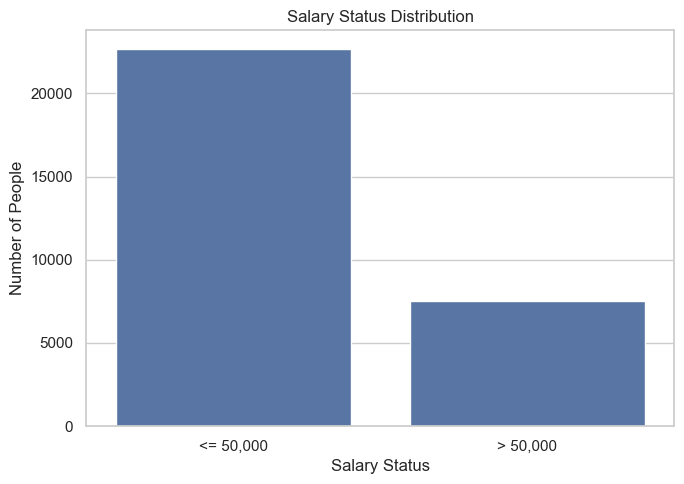

In [17]:
# =============================================================================
# SALARY STATUS DISTRIBUTION
# =============================================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=data2,
    x="SalStat"
)

plt.title("Salary Status Distribution")
plt.xlabel("Salary Status")
plt.ylabel("Number of People")

plt.xticks(
    [0, 1],
    ["<= 50,000", "> 50,000"]
)

plt.tight_layout()
plt.show()

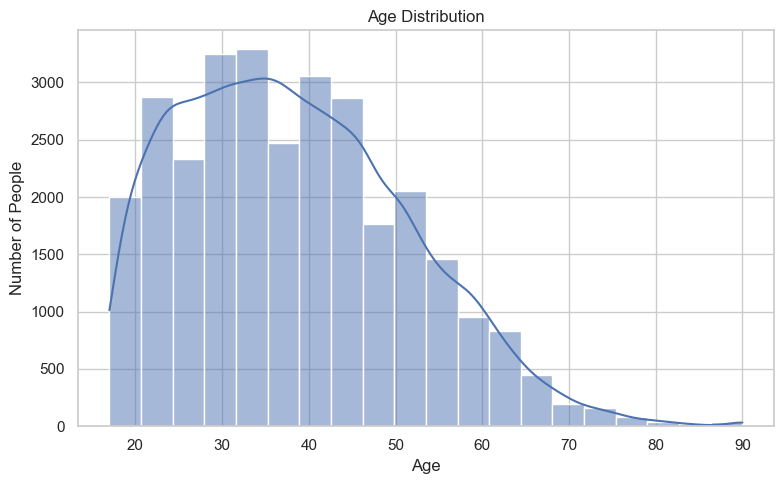

In [18]:
# =============================================================================
# AGE DISTRIBUTION
# =============================================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=data2,
    x="age",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of People")

plt.tight_layout()
plt.show()

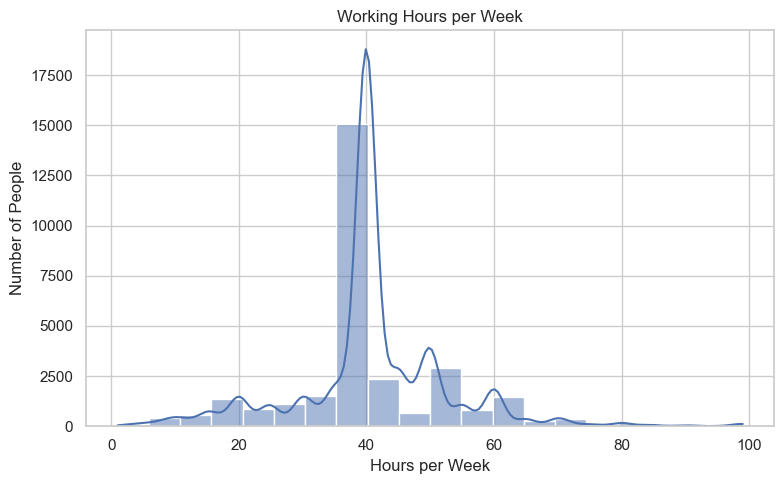

In [19]:
# =============================================================================
# HOURS PER WEEK DISTRIBUTION
# =============================================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=data2,
    x="hoursperweek",
    bins=20,
    kde=True
)

plt.title("Working Hours per Week")
plt.xlabel("Hours per Week")
plt.ylabel("Number of People")

plt.tight_layout()
plt.show()

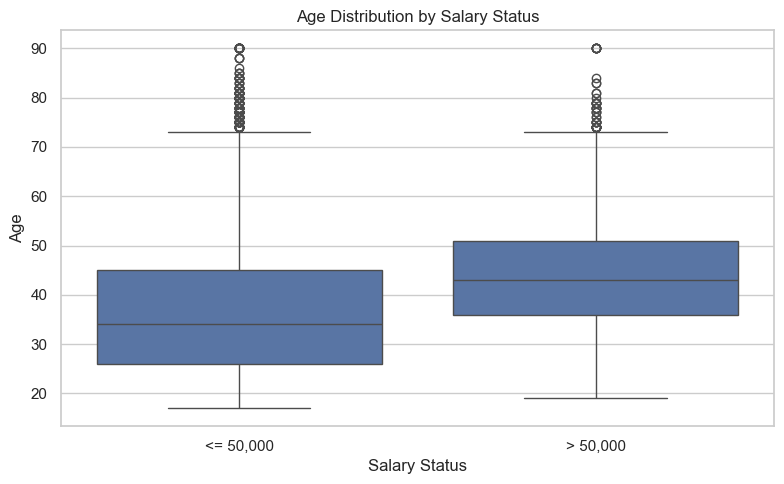

In [20]:
# =============================================================================
# AGE VS SALARY STATUS
# =============================================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data2,
    x="SalStat",
    y="age"
)

plt.title("Age Distribution by Salary Status")
plt.xlabel("Salary Status")
plt.ylabel("Age")

plt.xticks(
    [0, 1],
    ["<= 50,000", "> 50,000"]
)

plt.tight_layout()
plt.show()

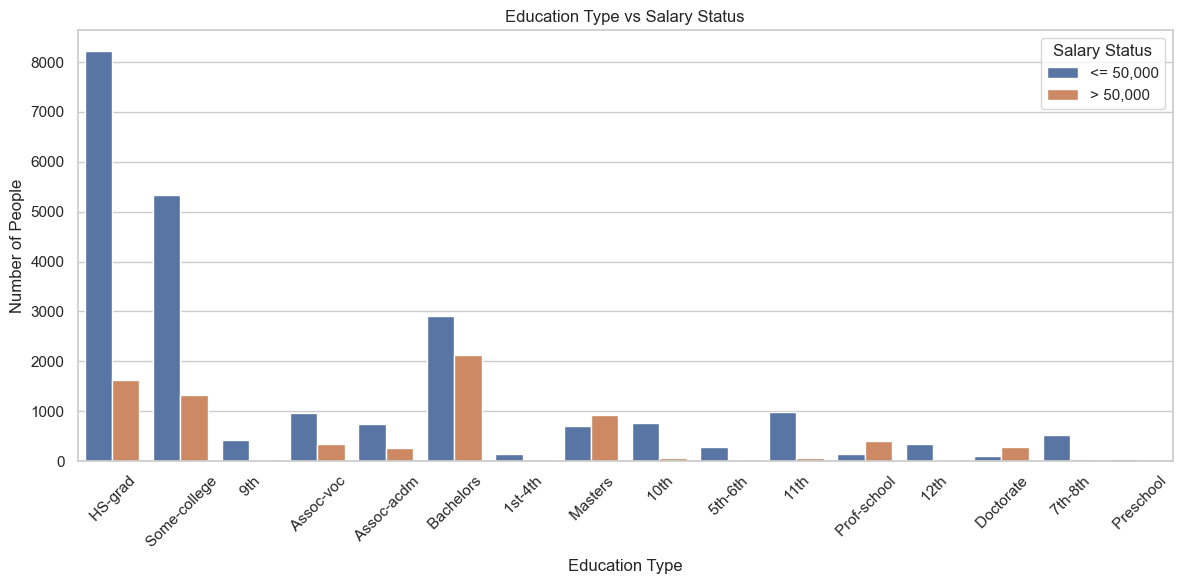

In [21]:
# =============================================================================
# EDUCATION TYPE VS SALARY STATUS
# =============================================================================

plt.figure(figsize=(12, 6))

sns.countplot(
    data=data2,
    x="EdType",
    hue="SalStat"
)

plt.title("Education Type vs Salary Status")
plt.xlabel("Education Type")
plt.ylabel("Number of People")

plt.xticks(rotation=45)

plt.legend(
    title="Salary Status",
    labels=["<= 50,000", "> 50,000"]
)

plt.tight_layout()
plt.show()

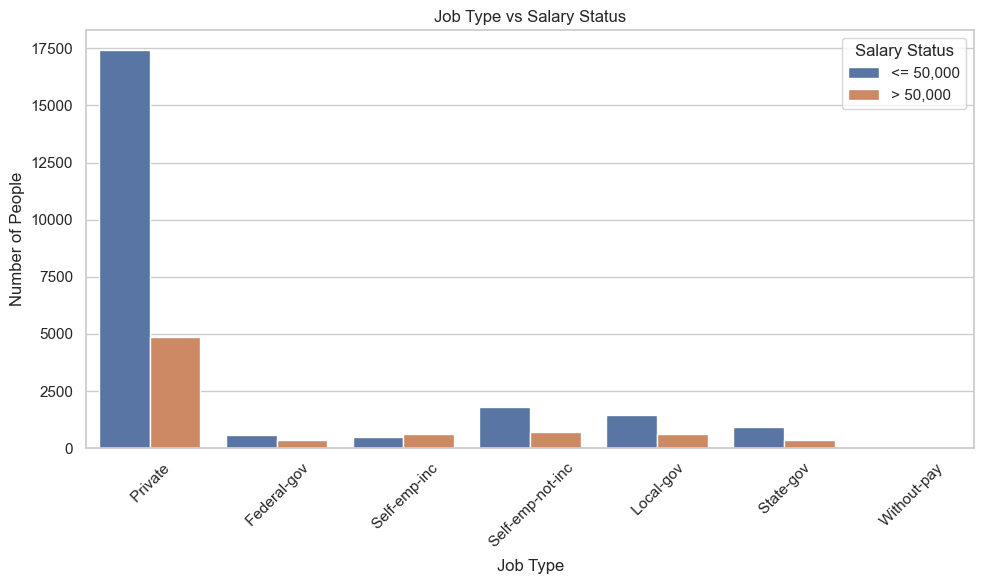

In [22]:
# =============================================================================
# JOB TYPE VS SALARY STATUS
# =============================================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=data2,
    x="JobType",
    hue="SalStat"
)

plt.title("Job Type vs Salary Status")
plt.xlabel("Job Type")
plt.ylabel("Number of People")

plt.xticks(rotation=45)

plt.legend(
    title="Salary Status",
    labels=["<= 50,000", "> 50,000"]
)

plt.tight_layout()
plt.show()

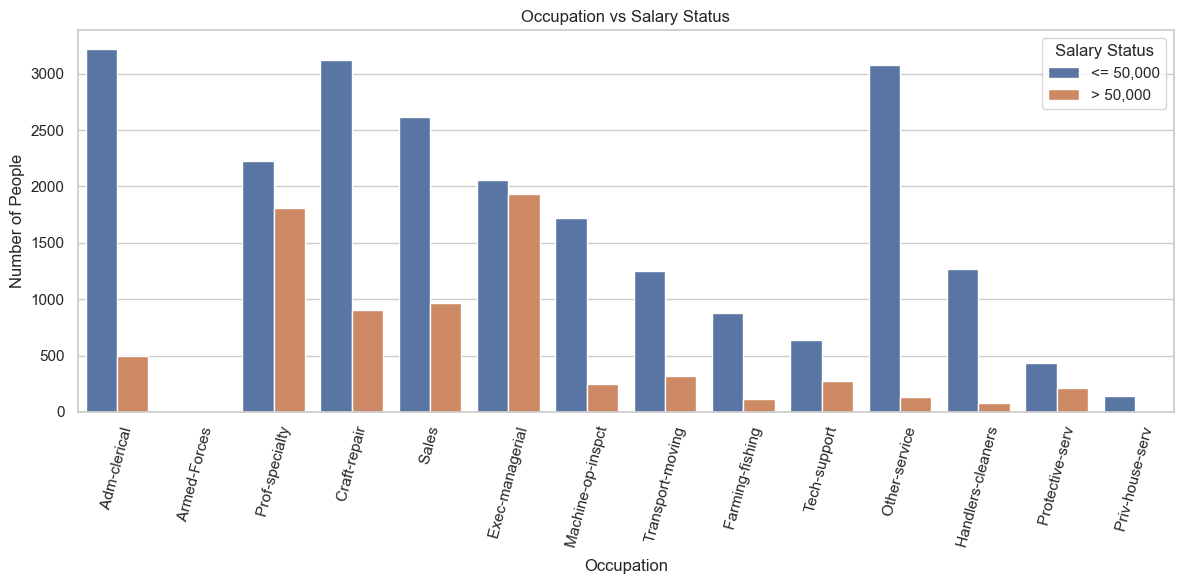

In [23]:
# =============================================================================
# OCCUPATION VS SALARY STATUS
# =============================================================================

plt.figure(figsize=(12, 6))

sns.countplot(
    data=data2,
    x="occupation",
    hue="SalStat"
)

plt.title("Occupation vs Salary Status")
plt.xlabel("Occupation")
plt.ylabel("Number of People")

plt.xticks(rotation=75)

plt.legend(
    title="Salary Status",
    labels=["<= 50,000", "> 50,000"]
)

plt.tight_layout()
plt.show()

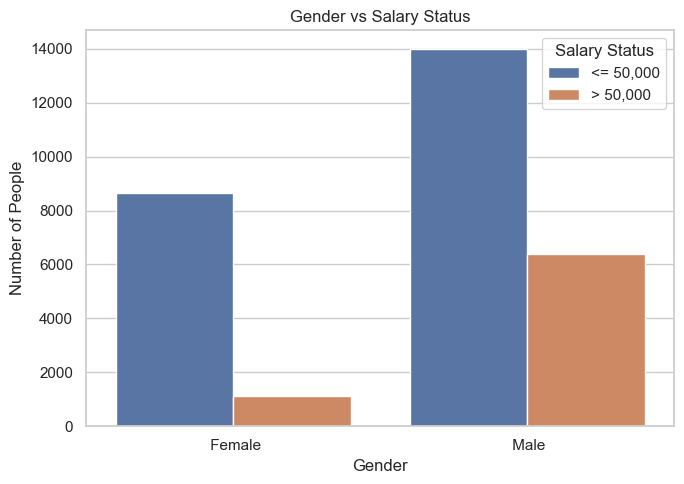

In [24]:
# =============================================================================
# GENDER VS SALARY STATUS
# =============================================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=data2,
    x="gender",
    hue="SalStat"
)

plt.title("Gender vs Salary Status")
plt.xlabel("Gender")
plt.ylabel("Number of People")

plt.legend(
    title="Salary Status",
    labels=["<= 50,000", "> 50,000"]
)

plt.tight_layout()
plt.show()

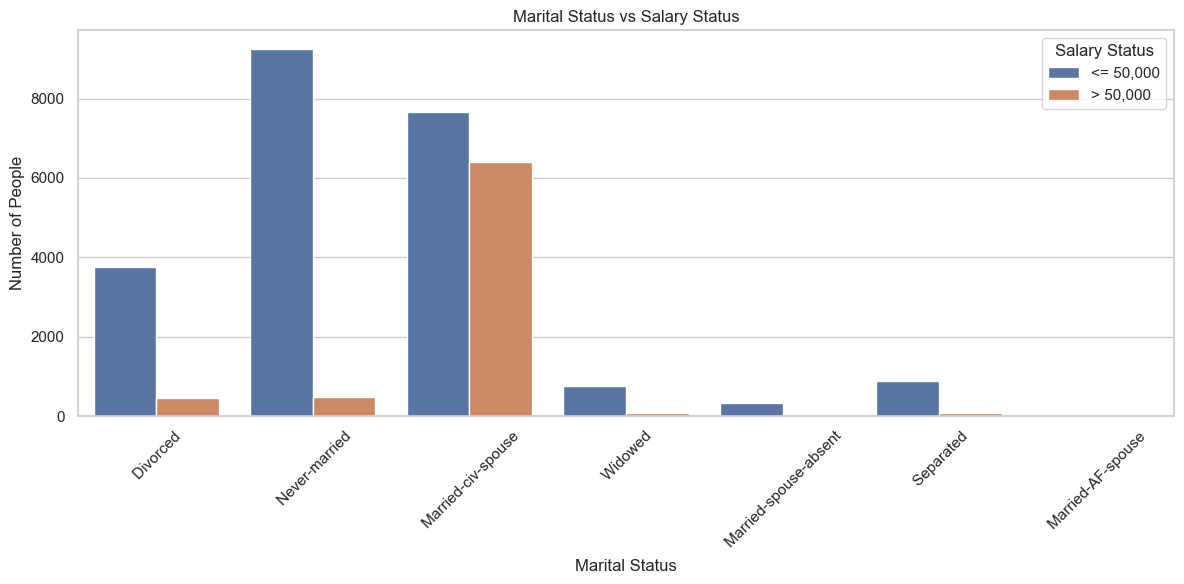

In [25]:
# =============================================================================
# MARITAL STATUS VS SALARY
# =============================================================================

plt.figure(figsize=(12, 6))

sns.countplot(
    data=data2,
    x="maritalstatus",
    hue="SalStat"
)

plt.title("Marital Status vs Salary Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of People")

plt.xticks(rotation=45)

plt.legend(
    title="Salary Status",
    labels=["<= 50,000", "> 50,000"]
)

plt.tight_layout()
plt.show()

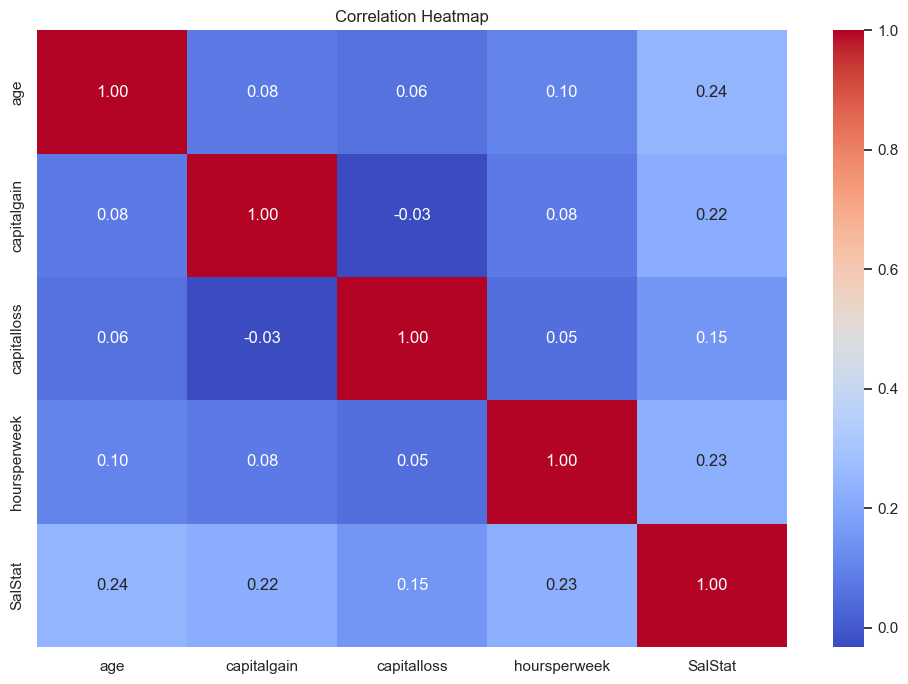

In [26]:
# =============================================================================
# CORRELATION HEATMAP
# =============================================================================

numeric_data = data2.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

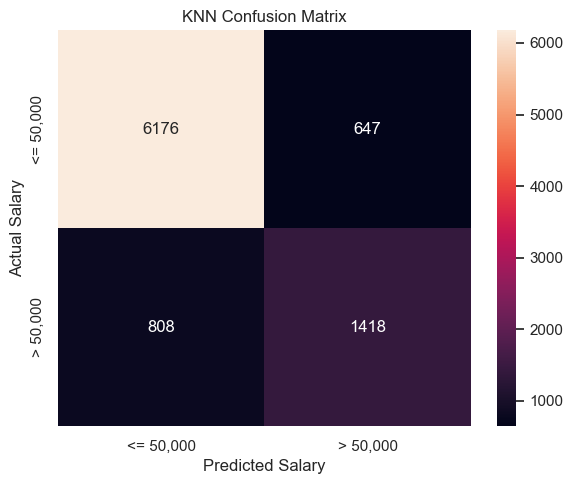

In [27]:
# =============================================================================
# CONFUSION MATRIX
# =============================================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix_result,
    annot=True,
    fmt="d",
    xticklabels=["<= 50,000", "> 50,000"],
    yticklabels=["<= 50,000", "> 50,000"]
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Salary")
plt.ylabel("Actual Salary")

plt.tight_layout()
plt.show()

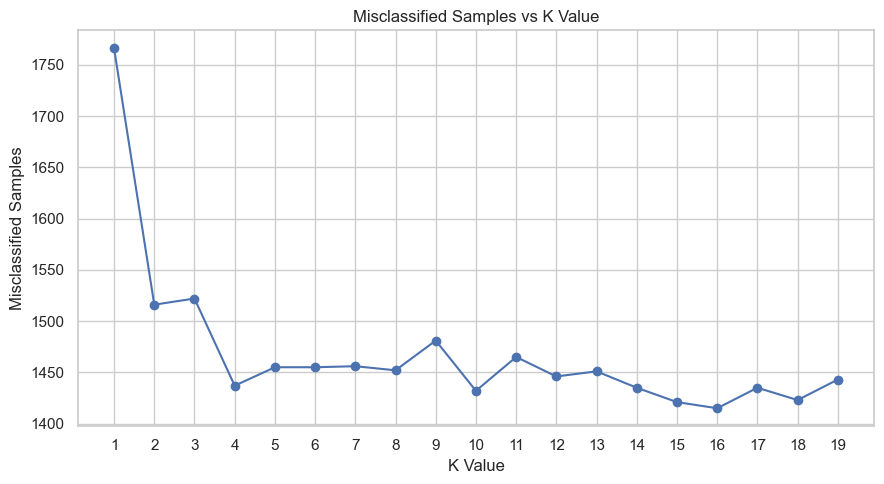

In [28]:
# =============================================================================
# MISCLASSIFIED SAMPLES VS K
# =============================================================================

k_values = range(1, 20)

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    misclassified_samples,
    marker="o"
)

plt.title("Misclassified Samples vs K Value")
plt.xlabel("K Value")
plt.ylabel("Misclassified Samples")

plt.xticks(k_values)

plt.tight_layout()
plt.show()

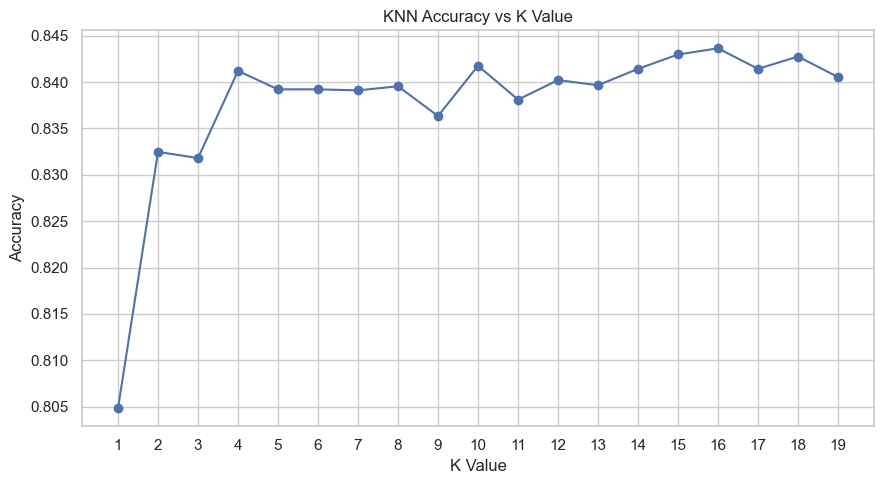

In [30]:
# =============================================================================
# ACCURACY VS K
# =============================================================================

accuracy_values = []

for k in range(1, 20):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(train_x, train_y)

    prediction_k = knn.predict(test_x)

    accuracy_k = accuracy_score(test_y, prediction_k)

    accuracy_values.append(accuracy_k)


plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    accuracy_values,
    marker="o"
)

plt.title("KNN Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.xticks(k_values)

plt.tight_layout()
plt.show()